In [2]:
import pandas as pd
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

c:\Users\Felipe Novais\.conda\envs\data_jobs\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.sample(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
396422,Senior Data Scientist,Senior Data Scientist,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-05-08 18:21:41,False,False,United Kingdom,NaN,NaN,NaN,MBN Solutions,"['python', 'gcp', 'numpy', 'pandas']","{'cloud': ['gcp'], 'libraries': ['numpy', 'pan..."
494890,Data Engineer,Data Engineering Specialist,"Monterrey, Nuevo Leon, Mexico",via BeBee México,Full-time,False,Mexico,2023-06-12 11:36:45,False,False,Mexico,NaN,NaN,NaN,Accenture,"['sql', 'shell', 'unix']","{'os': ['unix'], 'programming': ['sql', 'shell']}"
283673,Data Scientist,Head of Data,"Lisbon, Portugal",via BeBee Portugal,Full-time,False,Portugal,2023-07-03 07:24:11,True,False,Portugal,NaN,NaN,NaN,Truphone,"['sql', 'aws', 'spark', 'kafka']","{'cloud': ['aws'], 'libraries': ['spark', 'kaf..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


## Task: get the count of job titles

In [5]:
# method 1

df["job_title_short"].value_counts().sort_values(ascending=False)

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [6]:
# method 2

df.groupby("job_title_short").agg(
    job_count=("job_title_short", "count")
).sort_values("job_count", ascending=False).reset_index()

,job_title_short,job_count
0,Data Analyst,196075
1,Data Engineer,186241
2,Data Scientist,172286
3,Business Analyst,49063
4,Software Engineer,44929
5,Senior Data Engineer,44563
6,Senior Data Scientist,36957
7,Senior Data Analyst,29216
8,Machine Learning Engineer,14080
9,Cloud Engineer,12331


In [7]:
# method 3

df.groupby("job_title_short").size().sort_values(ascending=False)

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
dtype: int64

In [8]:
# method 4

series = df.pivot_table(index="job_title_short", aggfunc="count").loc[
    :,
    "job_posted_date"
]

series.sort_values(ascending=False)

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: job_posted_date, dtype: int64

## Task: get the median salary by job

In [9]:
# method 1

df.groupby("job_title_short").agg(
    median_yearly_salary=("salary_year_avg", "median")
).sort_values(by="median_yearly_salary", ascending=False).reset_index()

,job_title_short,median_yearly_salary
0,Senior Data Scientist,155500.0
1,Senior Data Engineer,147500.0
2,Data Scientist,127500.0
3,Data Engineer,125000.0
4,Senior Data Analyst,111175.0
5,Machine Learning Engineer,106415.0
6,Software Engineer,99150.0
7,Cloud Engineer,90000.0
8,Data Analyst,90000.0
9,Business Analyst,85000.0


In [10]:
# method 2

df.pivot_table(
    index="job_title_short", values="salary_year_avg", aggfunc="median"
).sort_values(by="salary_year_avg", ascending=False).reset_index()

,job_title_short,salary_year_avg
0,Senior Data Scientist,155500.0
1,Senior Data Engineer,147500.0
2,Data Scientist,127500.0
3,Data Engineer,125000.0
4,Senior Data Analyst,111175.0
5,Machine Learning Engineer,106415.0
6,Software Engineer,99150.0
7,Cloud Engineer,90000.0
8,Data Analyst,90000.0
9,Business Analyst,85000.0


## Task: get the median salary by job broken down by country

In [11]:
# method 1

df.pivot_table(index="job_title_short", columns="job_country", values="salary_year_avg", aggfunc="median")

job_country,Albania,Algeria,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Bangladesh,Belarus,...,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Vietnam,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,NaN,NaN,71100.00,NaN,70000.0,NaN,NaN,NaN,16500.0,NaN,...,NaN,72900.0,NaN,56700.0,90000.0,NaN,NaN,79200.0,NaN,NaN
Cloud Engineer,NaN,NaN,197500.00,NaN,110000.0,NaN,NaN,NaN,NaN,NaN,...,NaN,89100.0,NaN,NaN,116100.0,NaN,NaN,NaN,NaN,NaN
Data Analyst,49950.00,44100.0,92771.75,100500.0,109500.0,80850.00,NaN,NaN,NaN,400000.0,...,69300.0,72900.0,98500.0,87750.0,90000.0,100500.0,NaN,75550.0,NaN,63000.0
Data Engineer,NaN,45000.0,96773.00,48750.0,106712.5,147500.00,NaN,211000.0,97444.0,NaN,...,NaN,89100.0,97528.0,110000.0,125000.0,NaN,NaN,96773.0,NaN,NaN
Data Scientist,69981.25,NaN,71000.00,NaN,139216.0,71249.75,NaN,NaN,NaN,NaN,...,84200.0,131846.5,166419.5,105300.0,130000.0,NaN,30750.0,70000.0,90670.0,69085.0
Machine Learning Engineer,NaN,NaN,101029.00,87021.0,101029.0,89100.00,NaN,228750.0,69000.0,NaN,...,NaN,89100.0,62850.0,149653.0,150000.0,50000.0,NaN,57600.0,NaN,NaN
Senior Data Analyst,NaN,NaN,NaN,NaN,50640.0,89100.00,NaN,NaN,NaN,NaN,...,NaN,NaN,105837.5,111175.0,110000.0,NaN,NaN,105837.5,NaN,NaN
Senior Data Engineer,NaN,NaN,147500.00,NaN,147500.0,147500.00,NaN,173500.0,NaN,NaN,...,NaN,96773.0,NaN,147500.0,150000.0,NaN,NaN,147500.0,NaN,NaN
Senior Data Scientist,157500.00,NaN,NaN,NaN,157500.0,80850.00,NaN,NaN,NaN,NaN,...,NaN,157500.0,72000.0,157500.0,155000.0,57500.0,NaN,79200.0,NaN,NaN


In [12]:
# method 2

df.pivot_table(index="job_country", columns="job_title_short", values="salary_year_avg", aggfunc="median")

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


## Task: get the top 6 median salaries broken down by country and job title

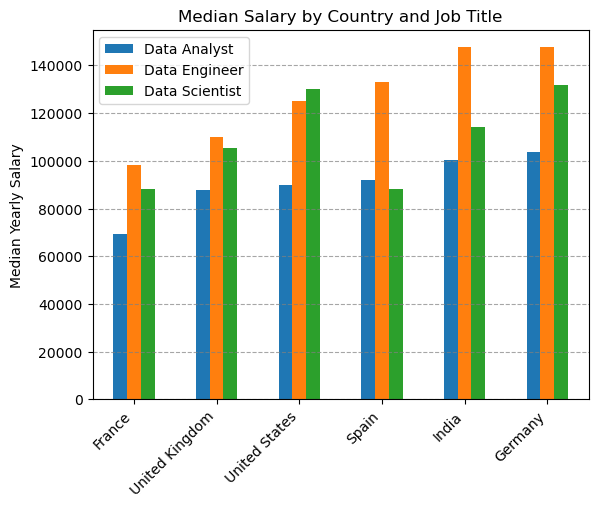

In [13]:
import matplotlib.pyplot as plt

top_countries = df["job_country"].value_counts().head(6).index
top_job_titles = df["job_title_short"].value_counts().head(3).index

top_countries_job_postings = df.loc[
    (df["job_country"].isin(top_countries)) & (df["job_title_short"].isin(top_job_titles))
]

plotting_data = top_countries_job_postings.pivot_table(
    index="job_country",
    columns="job_title_short", 
    values="salary_year_avg", 
    aggfunc="median"
).sort_values(by="Data Analyst", ascending=True)

plotting_data.plot(kind="bar")
plt.grid(True, axis="y", color="gray", linestyle="--", alpha=0.7)
plt.xlabel("")
plt.ylabel("Median Yearly Salary")
plt.title("Median Salary by Country and Job Title")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left")
plt.show()